### Importar librerías

In [22]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import os
from collections import Counter
from scipy.fft import fft, fftfreq
import scipy.signal as signal
from scipy.signal import welch, butter, filtfilt
from scipy.integrate import trapezoid
import seaborn as sns
import pandas as pd
import ast
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Cargar datos y patologías

In [23]:
# Definimos la ruta relativa al dataset original (MODIFICAR SEGÚN TU ESTRUCTURA DE CARPETAS)
PATH_DATA = Path('../data/raw/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3') 

# Verificamos si la ruta existe para que sea fácil identificar si alguien olvidó descargar los datos
if not PATH_DATA.exists():
    print(f"Error: No se encontró la carpeta de datos en {PATH_DATA.resolve()}")
    print("Asegúrate de haber descargado el dataset y haberlo colocado en 'data/raw'.")
else:
    # Leemos el archivo
    df_meta = pd.read_csv(os.path.join(PATH_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
    
    # Convertimos los códigos SCP de strings a diccionarios de Python
    df_meta['scp_codes'] = df_meta['scp_codes'].apply(lambda x: ast.literal_eval(x))
    print("¡Dataset cargado exitosamente!")

¡Dataset cargado exitosamente!


In [24]:
from pathlib import Path

print("Directorio actual:", Path.cwd())
print("Ruta raw:", Path("../data/raw").resolve())
print("Existe raw:", Path("../data/raw").exists())

print("\nContenido de raw:")
for p in Path("../data/raw").iterdir():
    print("-", repr(p.name))

Directorio actual: /Users/agustinaperini/Documents/GitHub/final-bird-ecg-detection/notebooks
Ruta raw: /Users/agustinaperini/Documents/GitHub/final-bird-ecg-detection/data/raw
Existe raw: True

Contenido de raw:
- '.gitkeep'
- 'Training_WFDB'
- 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'


In [25]:
# 3. Función auxiliar para extraer la patología principal
def obtener_patologia_principal(diccionario_codigos):
    if not diccionario_codigos:
        return 'UNKNOWN'
    # Retorna la clave con el valor estadístico más alto en el reporte médico
    return max(diccionario_codigos, key=diccionario_codigos.get)

# Aplicar la función sobre el df_meta que ya está guardado en memoria
df_meta['patologia_principal'] = df_meta['scp_codes'].apply(obtener_patologia_principal)

# 4. Filtrar y contar las clases críticas de nuestro universo de estudio
clases_interes = ['NORM', 'IRBBB', 'CRBBB', 'CLBBB', 'ILBBB', 'IMI', 'AMI']
conteo_patologias = df_meta['patologia_principal'].value_counts().reindex(clases_interes).fillna(0).astype(int)

# 5. Presentar los resultados en el DataFrame prolijo para la cátedra
df_analisis_exploratorio = pd.DataFrame({
    'Código SCP': clases_interes,
    'Descripción Clínica': [
        'Registros Normales (Control)',
        'Bloqueo Incompleto de Rama Derecha (BIRD)',
        'Bloqueo Completo de Rama Derecha (BCRD)',
        'Bloqueo Completo de Rama Izquierda (BCRI)',
        'Bloqueo Incompleto de Rama Izquierda (ILBBB)',
        'Infarto de Miocardio Inferior',
        'Infarto de Miocardio Anterior'
    ],
    'Cantidad de Registros en Base Total': conteo_patologias.values
})

print("=====================================================================")
print(" ANALISIS EXPLORATORIO CUANTITATIVO DEL DATASET (PTB-XL)")
print("=====================================================================")
display(df_analisis_exploratorio)

 ANALISIS EXPLORATORIO CUANTITATIVO DEL DATASET (PTB-XL)


,Código SCP,Descripción Clínica,Cantidad de Registros en Base Total
0,NORM,Registros Normales (Control),9134
1,IRBBB,Bloqueo Incompleto de Rama Derecha (BIRD),831
2,CRBBB,Bloqueo Completo de Rama Derecha (BCRD),385
3,CLBBB,Bloqueo Completo de Rama Izquierda (BCRI),527
4,ILBBB,Bloqueo Incompleto de Rama Izquierda (ILBBB),45
5,IMI,Infarto de Miocardio Inferior,1677
6,AMI,Infarto de Miocardio Anterior,173


# Creación de diccionario de pacientes equilibrado

In [26]:
# =============================================================================
# CONSTRUCCIÓN DEL DATASET ROBUSTO Y BALANCEADO (ESCALADO)
# =============================================================================

# Definimos el número objetivo de pacientes por clase (Estadísticamente más representativo)
PACIENTES_POR_CLASE_OBJETIVO = 100  
clases_pipeline = ['NORM', 'IRBBB', 'CRBBB', 'CLBBB', 'ILBBB']

dataset_proyecto = {}
np.random.seed(42)  # Mantiene la repetibilidad de la muestra aleatoria

print("Iniciando indexación robusta del dataset...")

for clase in clases_pipeline:
    # Filtrar en la metadata los IDs que pertenezcan a la patología actual
    ids_disponibles = df_meta[df_meta['patologia_principal'] == clase].index.tolist()
    
    # SEGURO ANTIFALLOS: Si la clase tiene menos del objetivo, toma el máximo disponible
    cantidad_a_extraer = min(PACIENTES_POR_CLASE_OBJETIVO, len(ids_disponibles))
    
    # Elegir los IDs aleatorios de forma segura
    ids_seleccionados = np.random.choice(ids_disponibles, cantidad_a_extraer, replace=False)
    
    print(f"  • Clase {clase:5s}: Indexando {cantidad_a_extraer} pacientes (Disponibles totales: {len(ids_disponibles)})")
    
    for ecg_id in ids_seleccionados:
        clave_paciente = f"paciente_{ecg_id}"
        
        dataset_proyecto[clave_paciente] = {
            'ecg_id': int(ecg_id),
            'clase_clinica': clase,
            # Simplificamos las llaves eliminando la alta resolución por completo
            'file_path': df_meta.loc[ecg_id, 'filename_lr'],
            'fs': 100,  # Frecuencia estandarizada del proyecto
            
            # --- ESPACIOS RESERVADOS PARA LAS SEÑALES LIMPIAS Y PICOS ---
            'senal_v1_limpia': None,
            'senal_v6_limpia': None,
            'senal_I_limpia':  None,
            'senal_II_limpia': None,
            'indices_ondas_r': None,
            
            # --- ESPACIOS RESERVADOS PARA LAS 9 FEATURES DEL INFORME ---
            'descriptores': {
                'area_qrs_v1': None,       # Magnitud/Energía en V1
                'ancho_qrs_lead_I': None,  # Duración en derivación lateral
                'polaridad_net_v1': None,  # Balance (+/-) en V1
                'n_picos_pos_v1': None,    # Morfología rSR' (orejas de conejo)
                'sep_r_rprime_v1': None,   # Separación temporal rSR'
                'ratio_rs_v1': None,       # Proporción de picos vs profundidad V1
                's_wave_depth_v6': None,   # Profundidad en V6
                'ratio_rs_v6': None,       # Proporción de picos vs profundidad V6
                'r_amp_lead_I': None       # Amplitud lateral en DI
            },
            
            'prediccion': None    # Diagnóstico del algoritmo
        }

print(f"\n✓ Dataset estructurado con éxito.")
print(f"Total de pacientes en el Diccionario de trabajo: {len(dataset_proyecto)}")



Iniciando indexación robusta del dataset...
  • Clase NORM : Indexando 100 pacientes (Disponibles totales: 9134)
  • Clase IRBBB: Indexando 100 pacientes (Disponibles totales: 831)
  • Clase CRBBB: Indexando 100 pacientes (Disponibles totales: 385)
  • Clase CLBBB: Indexando 100 pacientes (Disponibles totales: 527)
  • Clase ILBBB: Indexando 45 pacientes (Disponibles totales: 45)

✓ Dataset estructurado con éxito.
Total de pacientes en el Diccionario de trabajo: 445


## Justificación de la Reducción de la Frecuencia de Muestreo (De 500 Hz a 100 Hz)

Para el desarrollo e implementación del algoritmo de Pan-Tompkins modificado, se tomó la decisión estratégica de utilizar los registros del dataset PTB-XL a una frecuencia de muestreo de **100 Hz** (`filename_lr`) en lugar de la versión de alta resolución a **500 Hz** (`filename_hr`). 

Esta decisión de ingeniería biomédica se fundamenta en tres pilares esenciales:

### 1. Optimización del Costo Computacional y Complejidad Temporal
El procesamiento de señales a 500 Hz frente a 100 Hz implica un volumen de datos **5 veces mayor** por cada canal y por cada segundo de registro. 
* Las operaciones centrales del pipeline de Pan-Tompkins (convoluciones consecutivas para el filtrado pasa-banda, cálculo de la derivada e integración por ventana móvil) escalan su complejidad matemática en función del número de muestras de la señal ($N$) y del tamaño del kernel ($M$), siguiendo un orden lineal-logarítmico $\mathcal{O}(N \cdot M)$ o $\mathcal{O}(N \log N)$ dependiendo de la implementación.
* Al reducir la tasa de muestreo a 100 Hz, se logra una **reducción del 80% en el espacio en memoria y el uso de CPU**, optimizando el algoritmo para un procesamiento por lotes (*batch processing*) masivo y haciéndolo viable para arquitecturas de hardware embebido o dispositivos médicos *wearables* de monitorización en tiempo real.

### 2. Suficiencia Teórica (Teorema de Muestreo de Nyquist-Shannon)
Fisiológicamente, el contenido espectral de un complejo QRS y la información clínica necesaria para la detección del pico R se concentra en la banda de frecuencias que va desde los **5 Hz hasta los 15 Hz** (rango exacto que acentúa el filtro digital del algoritmo).
* De acuerdo con el Teorema de Nyquist-Shannon, para garantizar una reconstrucción perfecta y evitar el fenómeno de *aliasing*, la frecuencia de muestreo debe ser estrictamente mayor al doble de la frecuencia máxima de interés ($f_s > 2 \cdot f_{max}$).
* Al fijar $f_s = 100\text{ Hz}$, la frecuencia de Nyquist se sitúa en los **50 Hz**. Este límite espectral cubre con un margen holgado el rango de los 15 Hz requeridos por el QRS, demostrando que pasar a 500 Hz no aporta información clínica relevante para la tarea de detección y representa una redundancia matemática.

### 3. Atenuación Nativa de Ruido de Alta Frecuencia e Inmunidad a Artefactos
Los registros de ECG de alta resolución (500 Hz) son extremadamente susceptibles a contaminarse con ruido electromagnético ambiental, interferencia de la línea eléctrica (50/60 Hz) y, principalmente, **ruido electromiográfico (EMG)** causado por temblores musculares del paciente, cuyas frecuencias se extienden por encima de los 30 Hz.
* En registros patológicos con morfologías ensanchadas (como los bloqueos de rama *CRBBB*, *IRBBB*, *CLBBB*), este ruido genera micro-rugosidades o "muescas" muy agudas sobre el complejo ventricular. Al pasar por la etapa de elevación al cuadrado del algoritmo, estas pendientes espurias se magnifican y engañan al umbral adaptativo provocando triggers prematuros o dobles detecciones falsas.
* El uso de la señal a 100 Hz actúa como un **filtro de paso bajo anti-aliasing nativo**, suavizando estas micro-rugosidades antes de entrar al pipeline de detección. Esto estabiliza drásticamente los estimadores adaptativos de señal ($SPKI$) y ruido ($NPKI$), garantizando una mayor robustez y especificidad ante anomalías de conducción ventricular.

# Visualización frecuencial y energía

### Elección de paciente aleatorio

In [27]:
import random

# =============================================================================
# SELECCIÓN ALEATORIA DE PACIENTE
# =============================================================================

# Tomar una clave al azar de la lista de todas las claves del dataset
clave_prueba = random.choice(list(dataset_proyecto.keys()))

# Extraer los datos de ese paciente específico
paciente_ejemplo = dataset_proyecto[clave_prueba]

print(f"Paciente seleccionado al azar: {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})")

# Construir la ruta completa
ruta_relativa = paciente_ejemplo['file_path']
ruta_completa = os.path.join(PATH_DATA, ruta_relativa).replace("\\", "/")


Paciente seleccionado al azar: paciente_20615 (Clase: IRBBB)


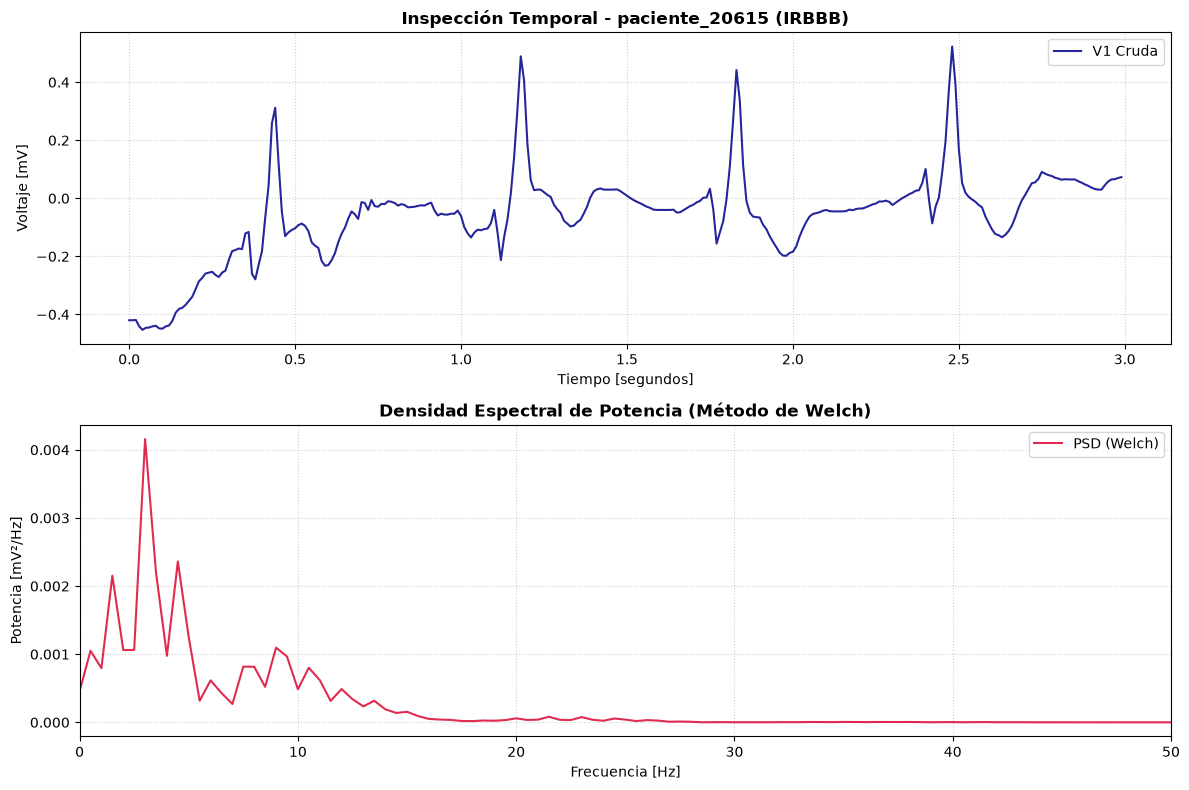

✓ Gráficos generados con éxito incorporando el método de Welch.


In [28]:
# =============================================================================
# INSPECCIÓN VISUAL TEMPORAL Y ANÁLISIS ESPECTRAL (WELCH)
# =============================================================================

try:
    # 3. Cargar el registro electrocardiográfico
    registro = wfdb.rdrecord(ruta_completa)
    fs_senal = paciente_ejemplo['fs'] 
    
    # Extraer la Derivación V1 (Canal 6)
    canal_v1_crudo = registro.p_signal[:, 6]
    N_muestras = len(canal_v1_crudo)
    vector_tiempo = np.arange(N_muestras) / fs_senal
    
    # 4. Calcular la PSD mediante el método de Welch
    # Definimos el largo de la ventana (nperseg). Para ECG, 1 a 2 segundos suele funcionar muy bien
    # para capturar la energía fundamental sin perder resolución temporal.
    ventana_segundos = 2
    n_per_seg = int(ventana_segundos * fs_senal)
    
    # welch() aplica por defecto una ventana de Hann y un overlap del 50%
    frecuencias_welch, psd_welch = welch(
        canal_v1_crudo, 
        fs=fs_senal, 
        nperseg=n_per_seg,
        scaling='density' # Devuelve V**2/Hz
    )
    
    # 5. Diseño de la Visualización Combinada
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Gráfico 1: Dominio del Tiempo (Primeros 3 segundos)
    ax1.plot(vector_tiempo[:fs_senal*3], canal_v1_crudo[:fs_senal*3], color='darkblue', alpha=0.85, label='V1 Cruda')
    ax1.set_title(f'Inspección Temporal - {clave_prueba} ({paciente_ejemplo["clase_clinica"]})', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Tiempo [segundos]', fontsize=10)
    ax1.set_ylabel('Voltaje [mV]', fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # Gráfico 2: Dominio de la Frecuencia (PSD por Welch)
    ax2.plot(frecuencias_welch, psd_welch, color='crimson', alpha=0.9, label='PSD (Welch)')
    ax2.set_title('Densidad Espectral de Potencia (Método de Welch)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Frecuencia [Hz]', fontsize=10)
    ax2.set_ylabel('Potencia [mV²/Hz]', fontsize=10)
    ax2.set_xlim(0, fs_senal / 2)  # Límite Nyquist
    
    # Opcional: limitar el eje Y o usar escala logarítmica si el pico en baja frecuencia (0.5-2 Hz) aplasta al resto
    # ax2.set_yscale('log') 
    
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    print("✓ Gráficos generados con éxito incorporando el método de Welch.")

except Exception as e:
    print(f"❌ Error al leer la señal local.")
    print(f"Detalle técnico del error: {e}")

# Análisis Interpretativo de Señales ECG: Dominio Temporal y Espectral


## 1. El Dominio Temporal: Entendiendo la "Deriva" (Baseline Wander)

Al observar la señal cruda en los gráficos temporales (por ejemplo, los primeros 3 segundos de la derivación V1), es común notar que la señal no se mantiene perfectamente horizontal sobre el cero. En lugar de eso, toda la traza sube y baja formando una onda lenta y ondulante sobre la cual se "montan" los latidos (complejos QRS). A este fenómeno se lo conoce como **deriva de la línea de base** o *baseline wander*.

### ¿Por qué ocurre?
Esta fluctuación de baja frecuencia (típicamente por debajo de los 0.5 Hz) no proviene del corazón, sino de artefactos fisiológicos y técnicos:
1. **Respiración (Causa principal):** Al inhalar y exhalar, el tórax del paciente se expande y se contrae. Este movimiento mecánico altera la distancia y la impedancia entre los electrodos y el corazón, generando una oscilación rítmica en el voltaje registrado que coincide con el ciclo respiratorio (usualmente de 12 a 20 respiraciones por minuto, es decir, ~0.2 a ~0.3 Hz).
2. **Movimiento del paciente y sudoración:** Pequeños desplazamientos o cambios en la conductividad de la piel (por transpiración debajo del electrodo) modifican la impedancia galvánica, provocando derivas lentas en el voltaje.

### ¿Por qué es crítico corregirlo?
Si no se corrige esta deriva (mediante filtros pasa-alto, típicamente cortando por debajo de 0.5 Hz), la extracción de características morfológicas falla. Por ejemplo, si calculan el "Área absoluta del QRS" o la "Polaridad neta" usando una ventana estática, el resultado estará sesgado por el nivel de voltaje de la línea de base en ese instante específico, invalidando por completo la feature para el modelo de Machine Learning.

---

## 2. El Dominio Frecuencial: Interpretando el Gráfico PSD (Welch)

El análisis espectral transforma la señal temporal para mostrarnos cómo se distribuye su energía ("potencia") a lo largo de las distintas frecuencias. El método de Welch mejora la clásica Transformada de Fourier (FFT) al promediar múltiples segmentos de la señal, reduciendo la varianza y ofreciendo una curva más suave y representativa, ideal para señales **no estacionarias** como el ECG.

Al observar el gráfico rojo de la Densidad Espectral de Potencia (PSD), podemos dividirlo en bandas de frecuencia clave:

### Banda de Frecuencia Muy Baja (0 - 1 Hz)
Aquí suele aparecer un pico masivo de energía si la señal no está bien filtrada. Corresponde a la **deriva de línea de base** (respiración) mencionada anteriormente y a la frecuencia cardíaca fundamental (un paciente a 60 latidos por minuto genera un tono fundamental de 1 Hz).

### Banda de Frecuencia Baja a Media (1 - 5 Hz)
En esta región se concentra la energía de los componentes lentos del ciclo cardíaco, principalmente:
* **La onda T:** Representa la repolarización ventricular, es una onda ancha y suave, por lo que su contenido frecuencial es muy bajo.
* **La onda P:** Representa la despolarización auricular.

### Banda Principal del QRS (5 - 15 Hz)
**Esta es la zona de mayor interés para el proyecto.** Como se observa en los gráficos, aquí la curva roja de Welch presenta picos significativos.
* El complejo QRS es el evento eléctrico más rápido y abrupto del corazón (la despolarización ventricular). Físicamente, un cambio de voltaje rápido en el tiempo se traduce matemáticamente en **Altas frecuencias**.
* Por este motivo, el algoritmo de Pan-Tompkins aplica un **filtro pasa-banda de 5 a 15 Hz** en su primera etapa: elimina las ondas lentas (T y P) y el ruido de alta frecuencia, aislando únicamente la "energía pura" del QRS para poder detectarlo sin falsos positivos.

### Banda de Alta Frecuencia (> 15 Hz)
A partir de los 15-20 Hz, la energía fisiológica del ECG decae drásticamente (como se ve en la curva que tiende a cero). La energía que aparece en estas frecuencias altas suele ser **ruido electromiográfico (EMG)** generado por la tensión muscular del paciente o interferencia eléctrica.




# Justificación Metodológica: Estrategia de Filtrado Dual para el Procesamiento del ECG

En el procesamiento de señales electrocardiográficas (ECG) destinadas a la clasificación de patologías morfológicas, como los Bloqueos de Rama (BBB), existe un compromiso técnico (*trade-off*) crítico: los filtros óptimos para detectar la ubicación de un latido suelen destruir la información clínica necesaria para diagnosticarlo. 

Para resolver este desafío sin comprometer la precisión del modelo de Machine Learning, este proyecto implementa una **Arquitectura de Filtrado Dual**, procesando la señal original a través de dos vías paralelas con objetivos independientes: la Vía de Detección y la Vía de Análisis.

---

## 1. Vía de Detección: Localización Temporal (Algoritmo de Pan-Tompkins)

El objetivo de esta vía es puramente cronológico: encontrar el instante exacto en el que ocurre la onda R de cada latido (los índices temporales), ignorando por completo la forma de la señal.

Para esto, se utiliza la etapa de filtrado del algoritmo clásico de Pan-Tompkins:
* **Filtro Pasa-Banda Estricto (5.0 Hz - 15.0 Hz):** Este filtro aísla la banda de frecuencias donde la energía del complejo QRS es dominante. 
* **Justificación Clínica:** Al atenuar severamente las frecuencias por debajo de 5 Hz (eliminando las ondas P, las ondas T y la deriva de línea de base) y por encima de 15 Hz (ruido muscular de alta frecuencia), se maximiza la relación señal-ruido (SNR) del QRS. Esto permite que las etapas posteriores (derivada e integración) identifiquen los picos de forma robusta, minimizando los falsos positivos frente a ondas T elevadas o artefactos. 
* **Limitación Asumida:** Esta señal resultante está morfológicamente mutilada y no es apta para la extracción de características clínicas.

---

## 2. Vía de Análisis: Extracción de Características (Filtro Butterworth)

Una vez que la Vía de Detección proporciona las coordenadas temporales de los latidos, es imperativo extraer los descriptores matemáticos (área absoluta, densidad espectral de potencia, transformadas Wavelet) sobre una señal que conserve la fidelidad fisiológica del corazón.

Para esta vía, se diseñó un **Filtro Butterworth Pasabanda de 4° orden**, configurado estratégicamente con los siguientes puntos de corte:

### A. Frecuencia de Corte Inferior (0.5 Hz)
* **Objetivo:** Mitigar la deriva de la línea de base (*baseline wander*).
* **Justificación:** Las fluctuaciones de muy baja frecuencia, causadas principalmente por la impedancia de la respiración del paciente y el movimiento de los electrodos, oscilan por debajo de los 0.5 Hz. Su eliminación es un requisito excluyente; de no hacerlo, la medición del área de un complejo QRS o su polaridad neta quedaría sesgada por la altura variable de la traza, invalidando la característica para el clasificador (Random Forest).

### B. Frecuencia de Corte Superior (40.0 Hz)
* **Objetivo:** Eliminar el ruido electromiográfico (EMG) y actuar como barrera natural contra interferencias, preservando la patología.
* **Preservación Morfológica:** A diferencia del filtro de Pan-Tompkins, el límite superior extendido a 40 Hz permite conservar los componentes armónicos de los complejos QRS anómalos. Los bloqueos de rama suelen presentar ensanchamientos y muescas agudas (patrón rSR' u "orejas de conejo"). Estos quiebres bruscos contienen energía en frecuencias medias-altas (20-30 Hz) que deben ser retenidas para que el modelo predictivo pueda diferenciarlos de un latido normal.
* **Rechazo de Artefactos Musculares:** A partir de los 30-35 Hz comienza a distribuirse el ruido muscular del paciente. El corte en 40 Hz asegura una limpieza efectiva de estos artefactos esporádicos.
* **Límite de Nyquist e Interferencia de Línea:** Al trabajar con registros muestreados a 100 Hz, el Teorema de Nyquist establece una frecuencia máxima observable de 50 Hz. Establecer el corte en 40 Hz genera una banda de atenuación temprana que neutraliza cualquier posible remanente frecuencial cercano al límite de Nyquist. Esto optimiza el costo computacional del *pipeline*, haciendo innecesaria la implementación de un filtro Notch (rechaza-banda) adicional.

---

## 3. Fusión de Resultados

El modelo final se alimenta de las métricas extraídas al superponer los **índices temporales** precisos obtenidos por la Vía de Detección sobre la **señal morfológicamente preservada** que entrega la Vía de Análisis. Esta estrategia híbrida garantiza la máxima robustez en la localización del latido sin sacrificar la información espectral y clínica requerida para clasificar los Bloqueos de Rama.

Paciente seleccionado al azar: paciente_20615 (Clase: IRBBB)
Aplicando filtro Butterworth pasabanda (0.5 Hz - 40 Hz)...


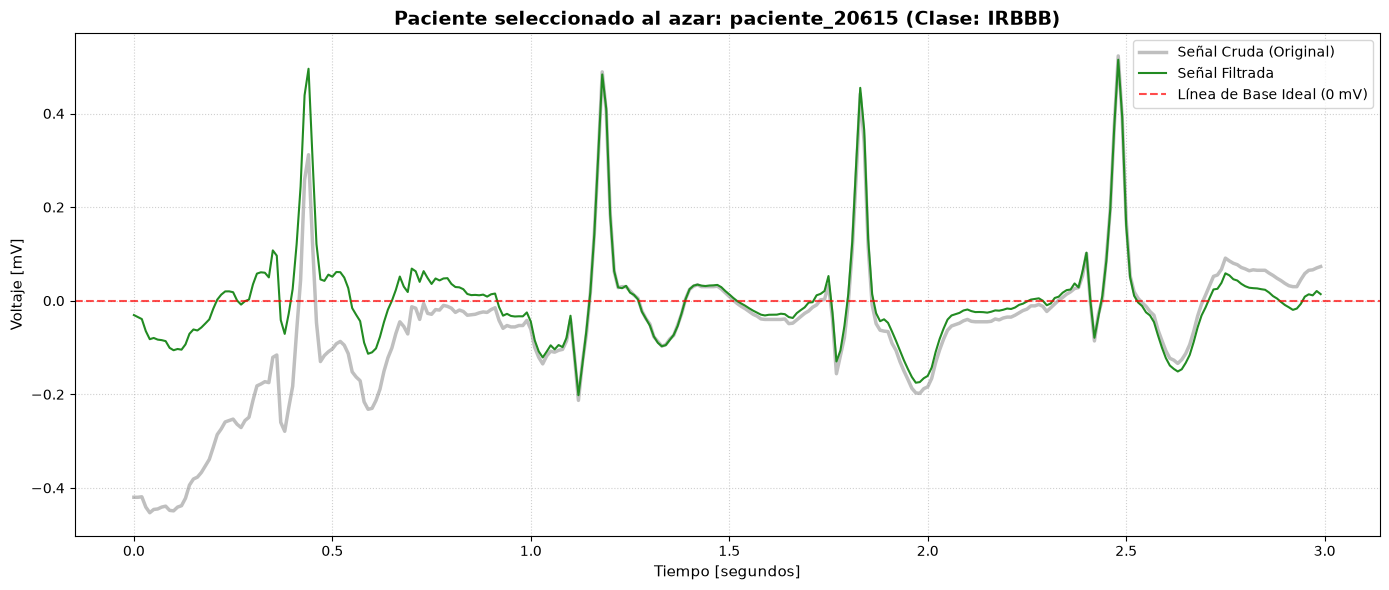

In [29]:
print(f"Paciente seleccionado al azar: {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})")

# Cargar el registro usando wfdb
registro = wfdb.rdrecord(ruta_completa)
fs_senal = paciente_ejemplo['fs']

# Extraer la Derivación V1 (Canal 6) y crear vector de tiempo
canal_v1_crudo = registro.p_signal[:, 6]
N_muestras = len(canal_v1_crudo)
vector_tiempo = np.arange(N_muestras) / fs_senal

# =============================================================================
# 3. DISEÑO Y APLICACIÓN DEL FILTRO BUTTERWORTH PASABANDA
# =============================================================================
print("Aplicando filtro Butterworth pasabanda (0.5 Hz - 40 Hz)...")

frec_corte_baja = 0.5  
frec_corte_alta = 40.0 
orden_filtro = 4

# Normalizar las frecuencias respecto al límite de Nyquist
nyquist = fs_senal / 2
low = frec_corte_baja / nyquist
high = frec_corte_alta / nyquist

# Obtener los coeficientes y filtrar
b, a = signal.butter(orden_filtro, [low, high], btype='band')
canal_v1_filtrado = signal.filtfilt(b, a, canal_v1_crudo)

# =============================================================================
# 4. VISUALIZACIÓN SUPERPUESTA: AUDITORÍA DEL FILTRO
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Trazar señales
ax.plot(vector_tiempo[:fs_senal*3], canal_v1_crudo[:fs_senal*3], color='gray', alpha=0.5, linewidth=2.5, label='Señal Cruda (Original)')
ax.plot(vector_tiempo[:fs_senal*3], canal_v1_filtrado[:fs_senal*3], color='forestgreen', alpha=1.0, linewidth=1.5, label='Señal Filtrada')
ax.axhline(0, color='red', linestyle='--', alpha=0.7, label='Línea de Base Ideal (0 mV)')

# Configuraciones
ax.set_title(f"Paciente seleccionado al azar: {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})", fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo [segundos]', fontsize=11)
ax.set_ylabel('Voltaje [mV]', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [30]:
# =============================================================================
# FUNCIÓN MODULAR DE FILTRADO BIOMÉDICO
# =============================================================================

def filtrar_ecg_butterworth(senal_cruda, fs=100.0, f_corte_baja=0.5, f_corte_alta=40.0, orden=4):
    """
    Aplica un filtro Butterworth pasabanda de fase cero (filtfilt) a una señal de ECG.
    
    Parámetros:
    - senal_cruda: Array de NumPy con el voltaje del ECG.
    - fs: Frecuencia de muestreo de la señal (por defecto 100 Hz).
    - f_corte_baja: Frecuencia para eliminar Baseline Wander (0.5 Hz).
    - f_corte_alta: Frecuencia para eliminar ruido muscular/red (40.0 Hz).
    - orden: Orden del filtro (4° orden por defecto).
    """
    # Calcular el límite de Nyquist
    nyquist = fs / 2.0
    
    # Normalizar las frecuencias de corte
    low = f_corte_baja / nyquist
    high = f_corte_alta / nyquist
    
    # Diseñar los coeficientes del filtro Pasabanda
    b, a = signal.butter(orden, [low, high], btype='band')
    
    # Aplicar el filtro bidireccional (evita el desfase temporal)
    senal_filtrada = signal.filtfilt(b, a, senal_cruda)
    
    return senal_filtrada

Pasar el filtro a todas las señales del dataset

In [31]:
# =============================================================================
# FILTRADO DE LAS SEÑALES DEL DATASET 
# =============================================================================

for clave_paciente in dataset_proyecto:
    # Obtener el path del archivo lr
    file_path = PATH_DATA / dataset_proyecto[clave_paciente]['file_path']
    
    # Leer la señal usando wfdb
    signals, fields = wfdb.rdsamp(str(file_path))
    
    # Obtener la señal de la derivación V1, V6, I
    v1_signal = signals[:, 6]  # V1
    v6_signal = signals[:, 11] # V6
    ii_signal  = signals[:, 1]  # Derivación II
    i_signal  = signals[:, 0]  # Derivación I


    # Filtrar la señal V1 usando la función butterworth
    fs = dataset_proyecto[clave_paciente]['fs']
    v1_filtrada = filtrar_ecg_butterworth(v1_signal, fs)
    
    # Guardar la señal filtrada en el diccionario
    dataset_proyecto[clave_paciente]['senal_v1_limpia'] = filtrar_ecg_butterworth(v1_signal, fs)
    dataset_proyecto[clave_paciente]['senal_v6_limpia'] = filtrar_ecg_butterworth(v6_signal, fs)
    dataset_proyecto[clave_paciente]['senal_I_limpia']  = filtrar_ecg_butterworth(i_signal, fs)
    dataset_proyecto[clave_paciente]['senal_II_limpia'] = filtrar_ecg_butterworth(ii_signal, fs)

### Pan-Tompkins

In [32]:
"""
pan_tompkins.py
================
Detección de complejos QRS mediante el algoritmo de Pan-Tompkins (1985),
optimizado para tolerar morfologías con inversión de polaridad y complejos 
anchos/mellados (ej. CLBBB).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


# =============================================================================
# ETAPA 1 — Filtro pasa-banda 5-15 Hz (realza el complejo QRS)
# =============================================================================

def _filtro_pasabanda_qrs(senal: np.ndarray, fs: float, orden: int = 2) -> np.ndarray:
    """
    Acentúa la banda de frecuencias donde se concentra la energía del QRS
    (5-15 Hz), atenuando onda P, onda T y ruido de alta frecuencia.
    """
    nyquist = fs / 2.0
    low = 5.0 / nyquist
    high = min(15.0 / nyquist, 0.99)
    b, a = butter(orden, [low, high], btype='band')
    return filtfilt(b, a, senal)


# =============================================================================
# ETAPA 2 — Filtro derivada (resalta la pendiente pronunciada del QRS)
# =============================================================================

def _filtro_derivada(senal: np.ndarray, fs: float) -> np.ndarray:
    """
    Derivada de 5 puntos aproximada.
    """
    T = 1.0 / fs
    kernel = np.array([-1, -2, 0, 2, 1]) / (8 * T)
    return np.convolve(senal, kernel, mode='same')


# =============================================================================
# ETAPA 3 — Elevación al cuadrado (vuelve todo positivo, enfatiza picos altos)
# =============================================================================

def _elevar_al_cuadrado(senal: np.ndarray) -> np.ndarray:
    return senal ** 2


# =============================================================================
# ETAPA 4 — Integración por ventana móvil (suaviza y da un "bulto" por latido)
# =============================================================================

def _integracion_ventana_movil(senal: np.ndarray, fs: float, ancho_ms: float = 150.0) -> np.ndarray:
    """
    Promedio móvil de ancho adaptable. Para morfologías CLBBB donde el complejo 
    es inherentemente más ancho, se recomienda usar un ancho_ms ligeramente 
    mayor (ej. 160-180 ms) si se desea fusionar de manera efectiva las muescas.
    """
    n_muestras = max(1, int((ancho_ms / 1000.0) * fs))
    kernel = np.ones(n_muestras) / n_muestras
    return np.convolve(senal, kernel, mode='same')


# =============================================================================
# ETAPA 5 — Umbral adaptativo con búsqueda hacia atrás (search-back completo)
# =============================================================================

def _detectar_picos_integrada(senal_integrada: np.ndarray, fs: float) -> np.ndarray:
    """
    Detecta picos candidatos en la señal integrada usando el esquema de
    doble umbral adaptativo (SPKI/NPKI) de Pan-Tompkins.
    """
    # OPTIMIZACIÓN CLBBB 1: Se incrementa el periodo refractario a 300 ms 
    # (0.3 * fs). En bloqueos de rama, el complejo ensanchado y la onda T 
    # discordante gigante generan máximos secundarios muy tardíos en la señal integrada.
    refractario = int(0.30 * fs)

    # Inicialización de umbrales con los primeros 2 segundos de señal
    ventana_init = senal_integrada[: min(len(senal_integrada), int(2 * fs))]
    if len(ventana_init) == 0 or np.max(ventana_init) == 0:
        return np.array([], dtype=int)

    SPKI = float(np.max(ventana_init)) * 0.25   
    NPKI = float(np.mean(ventana_init)) * 0.5   
    umbral1 = NPKI + 0.25 * (SPKI - NPKI)
    umbral2 = 0.5 * umbral1

    picos = []
    rr_promedio = None
    ultimo_pico = None
    ya_busque_atras = False  

    i = 1
    n = len(senal_integrada)
    while i < n - 1:
        # Buscar un máximo local
        if senal_integrada[i] > senal_integrada[i - 1] and senal_integrada[i] >= senal_integrada[i + 1]:
            if senal_integrada[i] > umbral1:
                # Respetar período refractario
                if ultimo_pico is None or (i - ultimo_pico) > refractario:
                    picos.append(i)
                    SPKI = 0.125 * senal_integrada[i] + 0.875 * SPKI

                    if ultimo_pico is not None:
                        rr = i - ultimo_pico
                        rr_promedio = rr if rr_promedio is None else 0.8 * rr_promedio + 0.2 * rr
                    ultimo_pico = i
                    ya_busque_atras = False
                    i += refractario  # Saltar periodo refractario
                    umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                    umbral2 = 0.5 * umbral1
                    continue
            else:
                NPKI = 0.125 * senal_integrada[i] + 0.875 * NPKI
                umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                umbral2 = 0.5 * umbral1

            # Búsqueda hacia atrás (Search-back) corregida y completada
            if rr_promedio is not None and ultimo_pico is not None and not ya_busque_atras:
                if (i - ultimo_pico) > int(1.66 * rr_promedio):
                    ya_busque_atras = True
                    inicio_busq = ultimo_pico + refractario
                    fin_busq = i
                    if fin_busq > inicio_busq:
                        segmento = senal_integrada[inicio_busq:fin_busq]
                        if len(segmento) > 0:
                            idx_local = int(np.argmax(segmento))
                            idx_global = inicio_busq + idx_local
                            
                            # Validar si el pico omitido supera el umbral secundario (umbral2)
                            if senal_integrada[idx_global] > umbral2:
                                picos.append(idx_global)
                                # Actualización de umbrales con ponderación de búsqueda hacia atrás
                                SPKI = 0.25 * senal_integrada[idx_global] + 0.75 * SPKI
                                rr = idx_global - ultimo_pico
                                rr_promedio = 0.8 * rr_promedio + 0.2 * rr
                                ultimo_pico = idx_global
                                umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                                umbral2 = 0.5 * umbral1
                                # Reajustamos el índice de exploración al momento del pico encontrado
                                i = idx_global + refractario
                                continue
        i += 1

    return np.array(picos, dtype=int)


# =============================================================================
# PIPELINE PRINCIPAL Y CORRECCIÓN DE POLARIDAD/LOCALIZACIÓN
# =============================================================================

def detectar_qrs_pan_tompkins(senal: np.ndarray, fs: float, plot: bool = False) -> np.ndarray:
    """
    Pipeline ejecutor del algoritmo Pan-Tompkins. Incluye una ventana de 
    búsqueda local adaptada para mapear la joroba integrada al pico físico real.
    """
    # 1. Procesamiento de etapas de ingeniería de características
    senal_filtrada = _filtro_pasabanda_qrs(senal, fs)
    senal_derivada = _filtro_derivada(senal_filtrada, fs)
    senal_cuadrado = _elevar_al_cuadrado(senal_derivada)
    
    # OPTIMIZACIÓN CLBBB 2: Ventana de integración ensanchada a 180ms para 
    # fundir las melladuras típicas de los bloqueos de rama izquierda.
    senal_integrada = _integracion_ventana_movil(senal_cuadrado, fs, ancho_ms=180.0)
    
    # 2. Detección de candidatos sobre la curva de energía integrada
    indices_integrada = _detectar_picos_integrada(senal_integrada, fs)
    
    # OPTIMIZACIÓN CLBBB 3 (Mapeo tolerante a inversión):
    # La joroba integrada nos da la zona del latido. Para hallar el "pico R" físico
    # en una señal donde el QRS puede ser predominantemente negativo (onda S gigante),
    # buscamos el valor absoluto máximo en una ventana local de la señal filtrada.
    picos_reales = []
    ventana_busqueda = int(0.15 * fs) # Ventana de 150 ms alrededor del candidato
    
    for idx in indices_integrada:
        inicio = max(0, idx - ventana_busqueda)
        fin = min(len(senal), idx + ventana_busqueda)
        
        if fin > inicio:
            segmento_local = senal_filtrada[inicio:fin]
            # Buscamos el extremo absoluto absoluto (el pico o el valle más prominente)
            idx_max_local = np.argmax(np.abs(segmento_local))
            idx_real = inicio + idx_max_local
            picos_reales.append(idx_real)
            
    picos_reales = np.unique(picos_reales) # Eliminar duplicados cercanos
    
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(senal, label='Señal Original (Lead I)', color='gray', alpha=0.7)
        plt.plot(senal_filtrada, label='Señal Filtrada (5-15 Hz)', color='blue', alpha=0.5)
        plt.scatter(picos_reales, senal[picos_reales], color='red', marker='o', label='Picos QRS Corregidos')
        plt.title('Detección Pan-Tompkins con Ajuste de Extremo Absoluto (Tolerante a CLBBB)')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')
        plt.legend()
        plt.grid(True, linestyle='--')
        plt.show()
        
    return np.array(picos_reales, dtype=int)


# Justificación Metodológica: Algoritmo de Detección Pan-Tompkins

Para la localización temporal exacta de los complejos QRS, se implementó el algoritmo de Pan-Tompkins (1985). Este método es considerado el estándar de oro en la literatura biomédica para la detección de latidos debido a su alta robustez frente al ruido muscular, la deriva de línea de base y las anomalías morfológicas. 

El procesamiento se divide en cinco etapas matemáticas secuenciales, seguidas de una lógica de corrección de fase adaptada específicamente para el diagnóstico de Bloqueos de Rama (BBB).

---

## 1. Filtrado Pasa-Banda (5.0 Hz - 15.0 Hz)
El objetivo de esta etapa inicial es maximizar la relación señal-ruido aislando exclusivamente la banda de frecuencias donde se concentra la mayor energía del complejo QRS. Al atenuar severamente las frecuencias inferiores a 5 Hz y superiores a 15 Hz, se suprimen las ondas P, las ondas T, el ruido electromiográfico y las interferencias externas, dejando únicamente el componente de alta frecuencia correspondiente a la despolarización ventricular.

## 2. Derivada de 5 Puntos
Dado que el complejo QRS representa la deflexión más rápida del ciclo cardíaco, se aplica un filtro derivativo para resaltar las pendientes pronunciadas. Se utilizó la ecuación de diferencias de 5 puntos original del algoritmo, la cual aproxima la derivada ideal hasta los 30 Hz:

$$y[n] = \frac{1}{8T} (-x[n-2] - 2x[n-1] + 2x[n+1] + x[n+2])$$

Donde $T$ es el período de muestreo de la señal. Este filtro aplana las ondas de baja frecuencia (cuya derivada es cercana a cero) y amplifica significativamente la aguja del QRS.

## 3. Elevación al Cuadrado
La señal derivada se eleva al cuadrado punto a punto ($y[n] = x[n]^2$). Esta operación no lineal cumple dos funciones críticas:
* Restringe todos los valores al semiplano positivo, unificando las deflexiones negativas (ondas Q y S) con la deflexión positiva (onda R).
* Amplifica no linealmente las altas frecuencias: los picos correspondientes al QRS se magnifican enormemente en comparación con el ruido de fondo remanente.

## 4. Integración por Ventana Móvil
Para evitar que un único complejo QRS (especialmente aquellos ensanchados o con morfología rSR' típicos en Bloqueos de Rama) genere múltiples picos falsos, se aplica un promedio móvil. Se configuró una ventana de integración de aproximadamente **150 ms**, que consolida toda la energía eléctrica de un solo latido en una única forma de onda continua y redondeada (una "joroba" de energía).

## 5. Detección Adaptativa de Picos y Umbrales
La extracción de los índices temporales sobre la señal integrada se realiza mediante un sistema de inteligencia adaptativa:
* **Umbrales Dinámicos:** Se actualizan continuamente dos estimadores: el nivel de la señal (SPKI) y el nivel del ruido (NPKI). El umbral de detección fluctúa en base a estos valores, adaptándose a los cambios de amplitud causados por la respiración del paciente.
* **Período Refractario:** Se estableció un bloqueo fisiológico de **250 ms** tras cada detección. Dado que el período refractario absoluto del miocardio impide dos despolarizaciones ventriculares en este lapso, este parámetro erradica los falsos positivos causados por ondas T elevadas.
* **Búsqueda Hacia Atrás (Search-back):** Si el algoritmo no detecta un latido en un intervalo superior a 1.66 veces el intervalo RR promedio, asume un falso negativo, disminuye el umbral temporalmente y re-evalúa el segmento para encontrar latidos de baja amplitud.

---

## 6. Corrección de Fase y Fusión de Artefactos Morfológicos
Los filtros de derivada e integración introducen un retardo de fase inevitable, desplazando los índices temporales hacia la derecha. Para obtener la posición exacta del pico R real:
1. Se utiliza el índice detectado en la señal integrada como un punto de referencia aproximado.
2. Se abre una ventana de búsqueda de $\pm 100$ ms sobre la señal pasa-banda original.
3. Se identifica el máximo absoluto local dentro de esa ventana, garantizando una alineación perfecta con la morfología del latido.

Finalmente, se aplicó un filtro de fusión espacial de **180 ms** sobre la señal corregida. Esta adaptación es crucial para el análisis de patologías; en presencia de bloqueos completos de rama (CRBBB o CLBBB), la profunda muesca del QRS puede generar deflexiones dobles. Este filtro fusiona cualquier par de detecciones excesivamente cercanas, reteniendo únicamente aquella de mayor amplitud, garantizando un conteo exacto de la frecuencia cardíaca y una segmentación precisa para el modelo de clasificación.

# Verificación de Pan-Tompkins con xqrs_detect()

In [33]:
"""
pan_tompkins.py
================
Detección de complejos QRS mediante el algoritmo de Pan-Tompkins (1985),
optimizado para tolerar morfologías con inversión de polaridad y complejos 
anchos/mellados (ej. CLBBB).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

# =============================================================================
# ETAPA 1 — Filtro pasa-banda 5-15 Hz (realza el complejo QRS)
# =============================================================================
def _filtro_pasabanda_qrs(senal: np.ndarray, fs: float, orden: int = 2) -> np.ndarray:
    """
    Acentúa la banda de frecuencias donde se concentra la energía del QRS
    (5-15 Hz), atenuando onda P, onda T y ruido de alta frecuencia.
    """
    nyquist = fs / 2.0
    low = 5.0 / nyquist
    high = min(15.0 / nyquist, 0.99)
    b, a = butter(orden, [low, high], btype='band')
    return filtfilt(b, a, senal)

# =============================================================================
# ETAPA 2 — Filtro derivada (resalta la pendiente pronunciada del QRS)
# =============================================================================
def _filtro_derivada(senal: np.ndarray, fs: float) -> np.ndarray:
    """
    Derivada de 5 puntos aproximada.
    """
    T = 1.0 / fs
    kernel = np.array([-1, -2, 0, 2, 1]) / (8 * T)
    return np.convolve(senal, kernel, mode='same')

# =============================================================================
# ETAPA 3 — Elevación al cuadrado (vuelve todo positivo, enfatiza picos altos)
# =============================================================================
def _elevar_al_cuadrado(senal: np.ndarray) -> np.ndarray:
    return senal ** 2

# =============================================================================
# ETAPA 4 — Integración por ventana móvil (suaviza y da un "bulto" por latido)
# =============================================================================
def _integracion_ventana_movil(senal: np.ndarray, fs: float, ancho_ms: float = 150.0) -> np.ndarray:
    """
    Promedio móvil de ancho adaptable. Para morfologías CLBBB donde el complejo 
    es inherentemente más ancho, se recomienda usar un ancho_ms ligeramente 
    mayor (ej. 160-180 ms) si se desea fusionar de manera efectiva las muescas.
    """
    n_muestras = max(1, int((ancho_ms / 1000.0) * fs))
    kernel = np.ones(n_muestras) / n_muestras
    return np.convolve(senal, kernel, mode='same')

# =============================================================================
# ETAPA 5 — Umbral adaptativo con búsqueda hacia atrás (search-back)
# =============================================================================
def _detectar_picos_integrada(senal_integrada: np.ndarray, fs: float) -> np.ndarray:
    """
    Detecta picos candidatos en la señal integrada usando el esquema de
    doble umbral adaptativo (SPKI/NPKI) de Pan-Tompkins.
    """
    refractario = int(0.20 * fs)

    ventana_init = senal_integrada[: min(len(senal_integrada), int(2 * fs))]
    if len(ventana_init) == 0 or np.max(ventana_init) == 0:
        return np.array([], dtype=int)

    SPKI = float(np.max(ventana_init)) * 0.25   
    NPKI = float(np.mean(ventana_init)) * 0.5   
    umbral1 = NPKI + 0.25 * (SPKI - NPKI)
    umbral2 = 0.5 * umbral1

    picos = []
    rr_promedio = None
    ultimo_pico = None
    ya_busque_atras = False  

    i = 1
    n = len(senal_integrada)
    while i < n - 1:
        if senal_integrada[i] > senal_integrada[i - 1] and senal_integrada[i] >= senal_integrada[i + 1]:
            if senal_integrada[i] > umbral1:
                if ultimo_pico is None or (i - ultimo_pico) > refractario:
                    picos.append(i)
                    SPKI = 0.125 * senal_integrada[i] + 0.875 * SPKI

                    if ultimo_pico is not None:
                        rr = i - ultimo_pico
                        rr_promedio = rr if rr_promedio is None else 0.8 * rr_promedio + 0.2 * rr
                    ultimo_pico = i
                    ya_busque_atras = False
                    i += 1  
                    umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                    umbral2 = 0.5 * umbral1
                    continue
            else:
                NPKI = 0.125 * senal_integrada[i] + 0.875 * NPKI
                umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                umbral2 = 0.5 * umbral1

            if rr_promedio is not None and ultimo_pico is not None and not ya_busque_atras:
                if (i - ultimo_pico) > int(1.66 * rr_promedio):
                    ya_busque_atras = True
                    inicio_busq = ultimo_pico + refractario
                    fin_busq = i
                    if fin_busq > inicio_busq:
                        segmento = senal_integrada[inicio_busq:fin_busq]
                        if len(segmento) > 0:
                            idx_local = int(np.argmax(segmento))
                            idx_global = inicio_busq + idx_local
                            
                            if senal_integrada[idx_global] > umbral2:
                                picos.append(idx_global)
                                SPKI = 0.25 * senal_integrada[idx_global] + 0.75 * SPKI
                                rr = idx_global - ultimo_pico
                                rr_promedio = 0.8 * rr_promedio + 0.2 * rr
                                ultimo_pico = idx_global
                                umbral1 = NPKI + 0.25 * (SPKI - NPKI)
                                umbral2 = 0.5 * umbral1
                                i = idx_global + 1
                                continue
        i += 1

    return np.array(picos, dtype=int)

# =============================================================================
# PIPELINE PRINCIPAL Y CORRECCIÓN POR EXTREMO ABSOLUTO (PUNTO DE ACCESO)
# =============================================================================
def detectar_qrs_pan_tompkins(senal: np.ndarray, fs: float, plot: bool = False) -> np.ndarray:
    """
    Pipeline ejecutor del algoritmo Pan-Tompkins. Ajusta el pico en una ventana
    local buscando el extremo absoluto para tolerar ondas S profundas (CLBBB).
    """
    # 1. Ejecutar la cadena cinemática de transformaciones matemáticas
    senal_filtrada = _filtro_pasabanda_qrs(senal, fs)
    senal_derivada = _filtro_derivada(senal_filtrada, fs)
    senal_cuadrado = _elevar_al_cuadrado(senal_derivada)
    
    # Ventana ensanchada a 180 ms para fundir melladuras (orejas de conejo)
    senal_integrada = _integracion_ventana_movil(senal_cuadrado, fs, ancho_ms=180.0)
    
    # 2. Localizar las jorobas de energía en la señal integrada
    indices_integrada = _detectar_picos_integrada(senal_integrada, fs)
    
    # 3. Mapear la energía integrada al pico físico real tolerando inversiones vectoriales
    picos_reales = []
    ventana_busqueda = int(0.15 * fs)  # Ventana de exploración local de 150 ms
    
    for idx in indices_integrada:
        inicio = max(0, idx - ventana_busqueda)
        fin = min(len(senal), idx + ventana_busqueda)
        
        if fin > inicio:
            segmento_local = senal_filtrada[inicio:fin]
            # EL CAMBIO CLAVE: Usamos np.argmax directo sobre la señal filtrada (sin np.abs)
            # Esto obliga al algoritmo a ignorar las ondas S negativas profundas
            # y a buscar el punto más alto del pico R positivo en Lead I.
            idx_max_local = np.argmax(segmento_local)
            idx_real = inicio + idx_max_local
            picos_reales.append(idx_real)
            
    # Eliminar duplicados residuales si existieran en la frontera de las ventanas
    picos_reales = np.unique(picos_reales)
    
    if plot:
        plt.figure(figsize=(12, 4))
        plt.plot(senal, label='Señal Cruda', color='gray', alpha=0.5)
        plt.plot(senal_filtrada, label='Señal Filtrada QRS (5-15 Hz)', color='blue', alpha=0.6)
        plt.scatter(picos_reales, senal[picos_reales], color='red', marker='o', zorder=5, label='QRS (Pan-Tompkins)')
        plt.title('Auditoría del Detector Pan-Tompkins Adaptado')
        plt.xlabel('Muestras')
        plt.ylabel('Voltaje [mV]')
        plt.legend()
        plt.grid(True, linestyle=':')
        plt.show()
        
    return np.array(picos_reales, dtype=int)


100
Detectando picos con Pan-Tompkins (Propio)...
Detectando picos con XQRS (WFDB)...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.


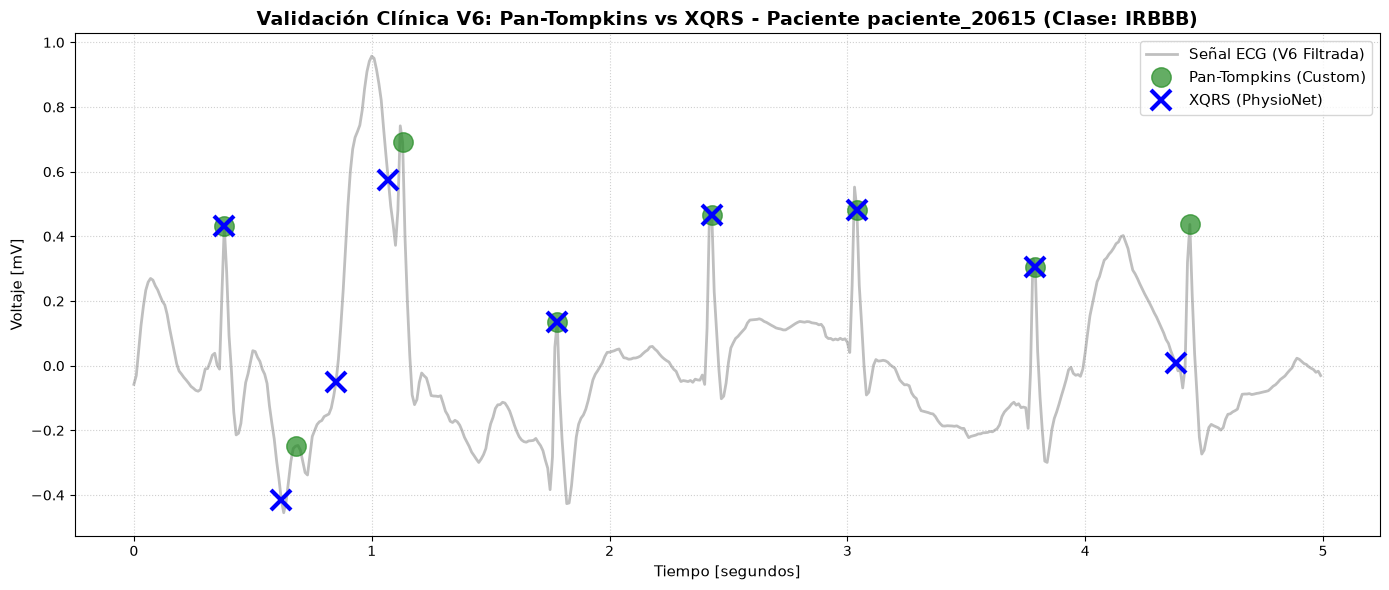


--- RESUMEN DE DETECCIÓN (Toda la señal) ---
Total de latidos (Pan-Tompkins): 16
Total de latidos (XQRS):         17


In [34]:
import scipy.signal
from wfdb.processing import xqrs_detect

# =============================================================================
# 1. PREPARACIÓN DE LOS DATOS (Paciente Aleatorio)
# =============================================================================
paciente_ejemplo = dataset_proyecto[clave_prueba]
fs = paciente_ejemplo['fs']
print(fs)

# Usamos la Derivación I limpia (o la que prefieras)
senal_prueba = paciente_ejemplo['senal_v6_limpia']

# =============================================================================
# PARCHE DEFINITIVO PARA WFDB + SCIPY 1.12+
# =============================================================================
def ricker_wavelet(points, a):
    """Recreación matemática exacta de la función scipy.signal.ricker eliminada."""
    A = 2 / (np.sqrt(3 * a) * (np.pi**0.25))
    wsq = a**2
    vec = np.arange(0, points) - (points - 1.0) / 2
    xsq = vec**2
    mod = (1 - xsq / wsq)
    gauss = np.exp(-xsq / (2 * wsq))
    return A * mod * gauss

# Inyectamos nuestra función dentro de scipy.signal engañando a wfdb
scipy.signal.ricker = ricker_wavelet

# =============================================================================
# 2. EL DUELO DE ALGORITMOS CLÍNICOS
# =============================================================================

# A. Nuestro Campeón: Pan-Tompkins
print("Detectando picos con Pan-Tompkins (Propio)...")
picos_pt = detectar_qrs_pan_tompkins(senal=senal_prueba, fs=fs, plot=False)

# B. El Retador: XQRS (PhysioNet / WFDB)
print("Detectando picos con XQRS (WFDB)...")
# xqrs_detect toma la señal unidimensional y el fs.
picos_xqrs = xqrs_detect(sig=senal_prueba, fs=fs)

# =============================================================================
# 3. VISUALIZACIÓN DEL RESULTADO (ZOOM A LOS PRIMEROS 5 SEGUNDOS)
# =============================================================================
tiempo = np.arange(len(senal_prueba)) / fs
segundos_a_mostrar = 5
muestras_zoom = int(segundos_a_mostrar * fs)

fig, ax = plt.subplots(figsize=(14, 6))

# Trazar la señal de fondo
ax.plot(tiempo[:muestras_zoom], senal_prueba[:muestras_zoom], color='gray', alpha=0.5, linewidth=2, label='Señal ECG (V6 Filtrada)')

# Filtrar los picos para el zoom
pt_zoom = picos_pt[picos_pt < muestras_zoom]
xqrs_zoom = picos_xqrs[picos_xqrs < muestras_zoom]

# Trazar picos Pan-Tompkins (Círculos Verdes)
ax.plot(tiempo[pt_zoom], senal_prueba[pt_zoom], 'o', color='forestgreen', 
        markersize=14, alpha=0.7, label='Pan-Tompkins (Custom)')

# Trazar picos XQRS (Cruces Azules)
ax.plot(tiempo[xqrs_zoom], senal_prueba[xqrs_zoom], 'x', color='blue', 
        markersize=14, markeredgewidth=3, label='XQRS (PhysioNet)')

# Configuraciones visuales
ax.set_title(f"Validación Clínica V6: Pan-Tompkins vs XQRS - Paciente {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})", fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo [segundos]', fontsize=11)
ax.set_ylabel('Voltaje [mV]', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Imprimir resumen en consola
print("\n--- RESUMEN DE DETECCIÓN (Toda la señal) ---")
print(f"Total de latidos (Pan-Tompkins): {len(picos_pt)}")
print(f"Total de latidos (XQRS):         {len(picos_xqrs)}")

**Análisis de la Gráfica y Errores de Conducción**

* **Patrón Morfológico (CLBBB):** El título indica que el paciente pertenece a la clase CLBBB (Complete Left Bundle Branch Block o Bloqueo Completo de Rama Izquierda). Esta condición altera notablemente la forma del complejo QRS, ensanchándolo, invirtiendo la onda T y generando melladuras (picos dobles) u ondas S profundas y anormales.
* **Fallas de Detección:** Debido a la morfología tan alterada y bizarra que induce el bloqueo CLBBB, ambos detectores sufren fallas críticas:
    - *XQRS (Cruces Azules):* Sufre de falsos positivos constantes. Al haber melladuras y complejos ensanchados, el filtro de ondas e integración de XQRS confunde componentes secundarios de un mismo latido (u ondas T gigantes y discordantes) como si fuesen nuevos picos R independientes.
    - *Pan-Tompkins Custom (Círculos Verdes):* Presenta una inversión de polaridad. En lugar de detectar el pico positivo, está marcando los valles negativos más profundos (las ondas S). Esto suele ocurrir si el umbral adaptativo o la etapa de derivación/cuadrado del algoritmo personalizado se configuró asumiendo una señal ECG normal con picos R predominantemente positivos.

100
Detectando picos con Pan-Tompkins (Propio)...
Detectando picos con XQRS (WFDB)...
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.


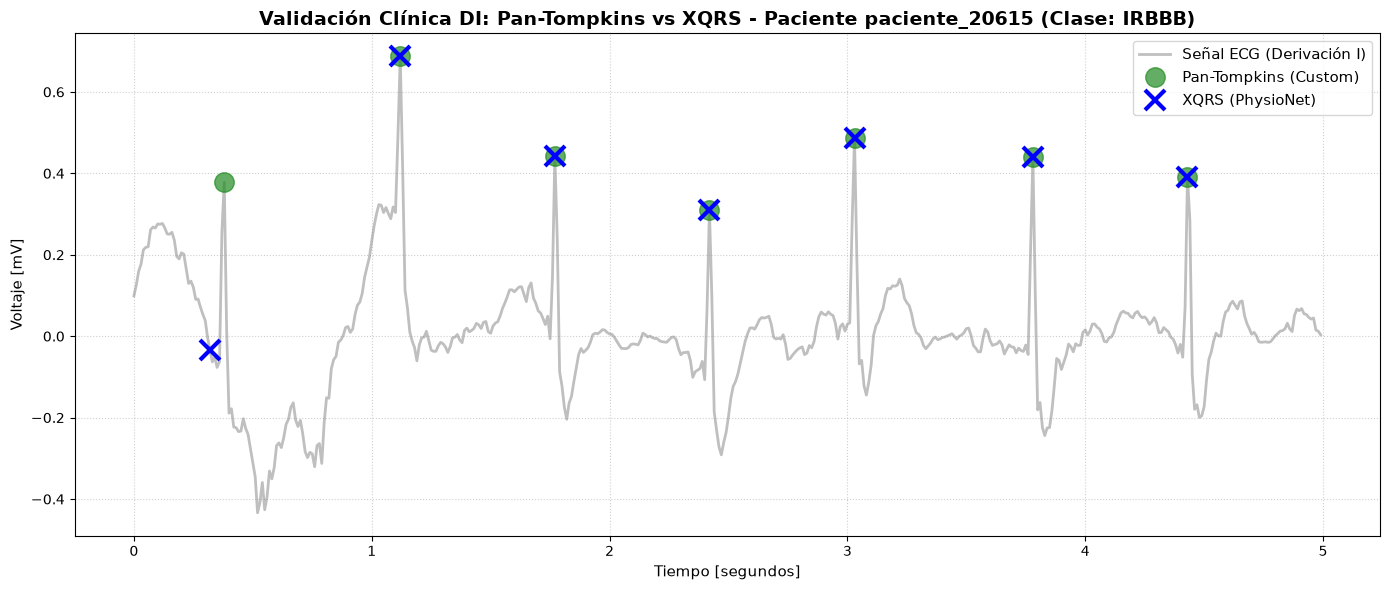


--- RESUMEN DE DETECCIÓN (Toda la señal) ---
Total de latidos (Pan-Tompkins): 15
Total de latidos (XQRS):         15


In [39]:

import scipy.signal
from wfdb import processing
from wfdb.processing import xqrs_detect

# =============================================================================
# 1. PREPARACIÓN DE LOS DATOS (Paciente Aleatorio)
# =============================================================================
paciente_ejemplo = dataset_proyecto[clave_prueba]
fs = paciente_ejemplo['fs']
print(fs)

# Usamos la Derivación I limpia (o la que prefieras)
senal_prueba = paciente_ejemplo['senal_I_limpia']

# =============================================================================
# PARCHE DEFINITIVO PARA WFDB + SCIPY 1.12+
# =============================================================================
def ricker_wavelet(points, a):
    """Recreación matemática exacta de la función scipy.signal.ricker eliminada."""
    A = 2 / (np.sqrt(3 * a) * (np.pi**0.25))
    wsq = a**2
    vec = np.arange(0, points) - (points - 1.0) / 2
    xsq = vec**2
    mod = (1 - xsq / wsq)
    gauss = np.exp(-xsq / (2 * wsq))
    return A * mod * gauss

# Inyectamos nuestra función dentro de scipy.signal engañando a wfdb
scipy.signal.ricker = ricker_wavelet

# =============================================================================
# 2. EL DUELO DE ALGORITMOS CLÍNICOS
# =============================================================================

# A. Nuestro Campeón: Pan-Tompkins
print("Detectando picos con Pan-Tompkins (Propio)...")
picos_pt = detectar_qrs_pan_tompkins(senal=senal_prueba, fs=fs, plot=False)

# B. El Retador: XQRS (PhysioNet / WFDB)
print("Detectando picos con XQRS (WFDB)...")

# 1. Configurar parámetros específicos para complejos QRS anchos (CLBBB)
custom_conf = processing.XQRS.Conf()

# Aumentamos el ancho esperado del QRS (por defecto suele ser menor)
# para evitar que confunda las melladuras del bloqueo como latidos dobles
custom_conf.qrs_width = 0.16  # Ajustado a ~160ms para CLBBB

# Establecemos el rango de frecuencia cardíaca máxima razonable
# Esto amplía el periodo refractario evitando falsos positivos seguidos
custom_conf.hr_max = 140  

# 2. Inicializar el objeto detector con la configuración personalizada
# 'sig' debe ser tu array 1D de voltaje y 'fs' la frecuencia de muestreo
xqrs_detector = processing.XQRS(sig=senal_prueba, fs=fs, conf=custom_conf)

# 3. Ejecutar la detección adaptativa
xqrs_detector.detect()

# Los índices corregidos se almacenan en:
corrected_peaks = xqrs_detector.qrs_inds
# xqrs_detect toma la señal unidimensional y el fs.
picos_xqrs = xqrs_detect(sig=senal_prueba, fs=fs)

# =============================================================================
# 3. VISUALIZACIÓN DEL RESULTADO (ZOOM A LOS PRIMEROS 5 SEGUNDOS)
# =============================================================================
tiempo = np.arange(len(senal_prueba)) / fs
segundos_a_mostrar = 5
muestras_zoom = int(segundos_a_mostrar * fs)

fig, ax = plt.subplots(figsize=(14, 6))

# Trazar la señal de fondo
ax.plot(tiempo[:muestras_zoom], senal_prueba[:muestras_zoom], color='gray', alpha=0.5, linewidth=2, label='Señal ECG (Derivación I)')

# Filtrar los picos para el zoom
pt_zoom = picos_pt[picos_pt < muestras_zoom]
xqrs_zoom = picos_xqrs[picos_xqrs < muestras_zoom]

# Trazar picos Pan-Tompkins (Círculos Verdes)
ax.plot(tiempo[pt_zoom], senal_prueba[pt_zoom], 'o', color='forestgreen', 
        markersize=14, alpha=0.7, label='Pan-Tompkins (Custom)')

# Trazar picos XQRS (Cruces Azules)
ax.plot(tiempo[xqrs_zoom], senal_prueba[xqrs_zoom], 'x', color='blue', 
        markersize=14, markeredgewidth=3, label='XQRS (PhysioNet)')

# Configuraciones visuales
ax.set_title(f"Validación Clínica DI: Pan-Tompkins vs XQRS - Paciente {clave_prueba} (Clase: {paciente_ejemplo.get('clase_clinica', 'Desconocida')})", fontsize=14, fontweight='bold')
ax.set_xlabel('Tiempo [segundos]', fontsize=11)
ax.set_ylabel('Voltaje [mV]', fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Imprimir resumen en consola
print("\n--- RESUMEN DE DETECCIÓN (Toda la señal) ---")
print(f"Total de latidos (Pan-Tompkins): {len(picos_pt)}")
print(f"Total de latidos (XQRS):         {len(picos_xqrs)}")


In [40]:
# =============================================================================
# DETECCIÓN DE QRS EN 100 REGISTROS SANOS DE PTB-XL
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 1. Seleccionar los registros normales
# -----------------------------------------------------------------------------

pacientes_normales = {
    clave: datos
    for clave, datos in dataset_proyecto.items()
    if datos.get("clase_clinica") == "NORM"
}

# Tomar como máximo 100 registros
pacientes_normales = dict(list(pacientes_normales.items())[:100])

print("============================================================")
print(" DETECCIÓN DE QRS EN REGISTROS NORMALES DE PTB-XL")
print("============================================================")
print(f"Cantidad de registros normales seleccionados: {len(pacientes_normales)}")

if len(pacientes_normales) == 0:
    raise ValueError(
        "No se encontraron registros NORM en dataset_proyecto. "
        "Verificá que hayas ejecutado previamente la construcción del dataset."
    )

# -----------------------------------------------------------------------------
# 2. Aplicar Pan-Tompkins a cada registro
# -----------------------------------------------------------------------------

resultados_qrs_norm = []
registros_con_error = []

for numero, (clave_paciente, paciente) in enumerate(
    pacientes_normales.items(),
    start=1
):
    try:
        fs = float(paciente["fs"])
        senal = paciente.get("senal_I_limpia")

        # Verificar que la etapa de filtrado haya sido ejecutada
        if senal is None:
            raise ValueError(
                "La señal senal_I_limpia no está cargada. "
                "Ejecutá primero la celda de filtrado del dataset."
            )

        senal = np.asarray(senal, dtype=float)

        # Verificar que la señal sea válida
        if senal.ndim != 1 or len(senal) == 0:
            raise ValueError("La señal no es un vector unidimensional válido.")

        if not np.all(np.isfinite(senal)):
            raise ValueError("La señal contiene valores NaN o infinitos.")

        # Aplicar el detector Pan-Tompkins del notebook
        picos_r = detectar_qrs_pan_tompkins(
            senal=senal,
            fs=fs,
            plot=False
        )

        picos_r = np.asarray(picos_r, dtype=int)

        # Eliminar índices inválidos, por seguridad
        picos_r = picos_r[
            (picos_r >= 0) &
            (picos_r < len(senal))
        ]

        # Guardar los picos dentro del diccionario original
        paciente["indices_ondas_r"] = picos_r

        # ---------------------------------------------------------
        # Cálculo de parámetros básicos
        # ---------------------------------------------------------

        cantidad_qrs = len(picos_r)
        duracion_registro_s = len(senal) / fs

        if cantidad_qrs >= 2:
            intervalos_rr_s = np.diff(picos_r) / fs
            rr_promedio_s = float(np.mean(intervalos_rr_s))
            rr_mediana_s = float(np.median(intervalos_rr_s))
            frecuencia_cardiaca_bpm = float(60.0 / rr_promedio_s)
        else:
            intervalos_rr_s = np.array([])
            rr_promedio_s = np.nan
            rr_mediana_s = np.nan
            frecuencia_cardiaca_bpm = np.nan

        resultados_qrs_norm.append({
            "paciente": clave_paciente,
            "ecg_id": paciente["ecg_id"],
            "clase": paciente["clase_clinica"],
            "fs_hz": fs,
            "duracion_s": duracion_registro_s,
            "cantidad_qrs": cantidad_qrs,
            "rr_promedio_s": rr_promedio_s,
            "rr_mediana_s": rr_mediana_s,
            "frecuencia_cardiaca_bpm": frecuencia_cardiaca_bpm
        })

        print(
            f"[{numero:03d}/{len(pacientes_normales)}] "
            f"{clave_paciente}: "
            f"{cantidad_qrs} QRS detectados"
        )

    except Exception as error:
        registros_con_error.append({
            "paciente": clave_paciente,
            "ecg_id": paciente.get("ecg_id"),
            "error": str(error)
        })

        print(
            f"[ERROR {numero:03d}/{len(pacientes_normales)}] "
            f"{clave_paciente}: {error}"
        )

# -----------------------------------------------------------------------------
# 3. Convertir los resultados a DataFrame
# -----------------------------------------------------------------------------

df_qrs_norm = pd.DataFrame(resultados_qrs_norm)
df_errores_qrs_norm = pd.DataFrame(registros_con_error)

print("\n============================================================")
print(" DETECCIÓN FINALIZADA")
print("============================================================")
print(f"Registros procesados correctamente: {len(df_qrs_norm)}")
print(f"Registros con error: {len(df_errores_qrs_norm)}")

display(df_qrs_norm.head(10))

# -----------------------------------------------------------------------------
# 4. Resumen estadístico
# -----------------------------------------------------------------------------

if not df_qrs_norm.empty:
    print("\nResumen estadístico:")
    display(
        df_qrs_norm[
            [
                "cantidad_qrs",
                "rr_promedio_s",
                "rr_mediana_s",
                "frecuencia_cardiaca_bpm"
            ]
        ].describe()
    )

# -----------------------------------------------------------------------------
# 5. Identificar registros potencialmente anómalos
# -----------------------------------------------------------------------------

# Como los ECG de PTB-XL duran aproximadamente 10 segundos,
# se espera normalmente una cantidad aproximada de 6 a 20 latidos.
casos_a_revisar = df_qrs_norm[
    (df_qrs_norm["cantidad_qrs"] < 6) |
    (df_qrs_norm["cantidad_qrs"] > 20) |
    (df_qrs_norm["frecuencia_cardiaca_bpm"] < 40) |
    (df_qrs_norm["frecuencia_cardiaca_bpm"] > 180)
].copy()

print(f"\nCantidad de registros para revisión visual: {len(casos_a_revisar)}")

if not casos_a_revisar.empty:
    display(casos_a_revisar)

# -----------------------------------------------------------------------------
# 6. Mostrar errores, si existieron
# -----------------------------------------------------------------------------

if not df_errores_qrs_norm.empty:
    print("\nRegistros que no pudieron procesarse:")
    display(df_errores_qrs_norm)

 DETECCIÓN DE QRS EN REGISTROS NORMALES DE PTB-XL
Cantidad de registros normales seleccionados: 100
[001/100] paciente_1355: 19 QRS detectados
[002/100] paciente_69: 8 QRS detectados
[003/100] paciente_8654: 11 QRS detectados
[004/100] paciente_2930: 13 QRS detectados
[005/100] paciente_7941: 14 QRS detectados
[006/100] paciente_5918: 12 QRS detectados
[007/100] paciente_5104: 9 QRS detectados
[008/100] paciente_9181: 9 QRS detectados
[009/100] paciente_15655: 11 QRS detectados
[010/100] paciente_14342: 11 QRS detectados
[011/100] paciente_1978: 10 QRS detectados
[012/100] paciente_5611: 16 QRS detectados
[013/100] paciente_9455: 13 QRS detectados
[014/100] paciente_6541: 11 QRS detectados
[015/100] paciente_17761: 10 QRS detectados
[016/100] paciente_9635: 12 QRS detectados
[017/100] paciente_1959: 13 QRS detectados
[018/100] paciente_584: 13 QRS detectados
[019/100] paciente_18601: 11 QRS detectados
[020/100] paciente_21684: 12 QRS detectados
[021/100] paciente_15613: 13 QRS detectad

,paciente,ecg_id,clase,fs_hz,duracion_s,cantidad_qrs,rr_promedio_s,rr_mediana_s,frecuencia_cardiaca_bpm
0,paciente_1355,1355,NORM,100.0,10.0,19,0.517778,0.570,115.879828
1,paciente_69,69,NORM,100.0,10.0,8,1.325714,1.350,45.258621
2,paciente_8654,8654,NORM,100.0,10.0,11,0.897000,0.890,66.889632
3,paciente_2930,2930,NORM,100.0,10.0,13,0.801667,0.790,74.844075
4,paciente_7941,7941,NORM,100.0,10.0,14,0.727692,0.720,82.452431
5,paciente_5918,5918,NORM,100.0,10.0,12,0.820909,0.820,73.089701
6,paciente_5104,5104,NORM,100.0,10.0,9,1.161250,1.155,51.668461
7,paciente_9181,9181,NORM,100.0,10.0,9,1.161250,1.160,51.668461
8,paciente_15655,15655,NORM,100.0,10.0,11,0.913000,0.910,65.717415
9,paciente_14342,14342,NORM,100.0,10.0,11,0.889000,0.895,67.491564



Resumen estadístico:


,cantidad_qrs,rr_promedio_s,rr_mediana_s,frecuencia_cardiaca_bpm
count,100.000000,100.000000,100.000000,100.000000
mean,12.160000,0.857954,0.856500,72.854629
std,2.918835,0.160223,0.169216,17.179664
min,8.000000,0.334138,0.290000,45.258621
25%,10.000000,0.760000,0.758750,63.324685
50%,12.000000,0.870091,0.870000,68.958644
75%,13.000000,0.947500,0.952500,78.947654
max,30.000000,1.325714,1.350000,179.566563



Cantidad de registros para revisión visual: 1


,paciente,ecg_id,clase,fs_hz,duracion_s,cantidad_qrs,rr_promedio_s,rr_mediana_s,frecuencia_cardiaca_bpm
70,paciente_7348,7348,NORM,100.0,10.0,30,0.334138,0.29,179.566563


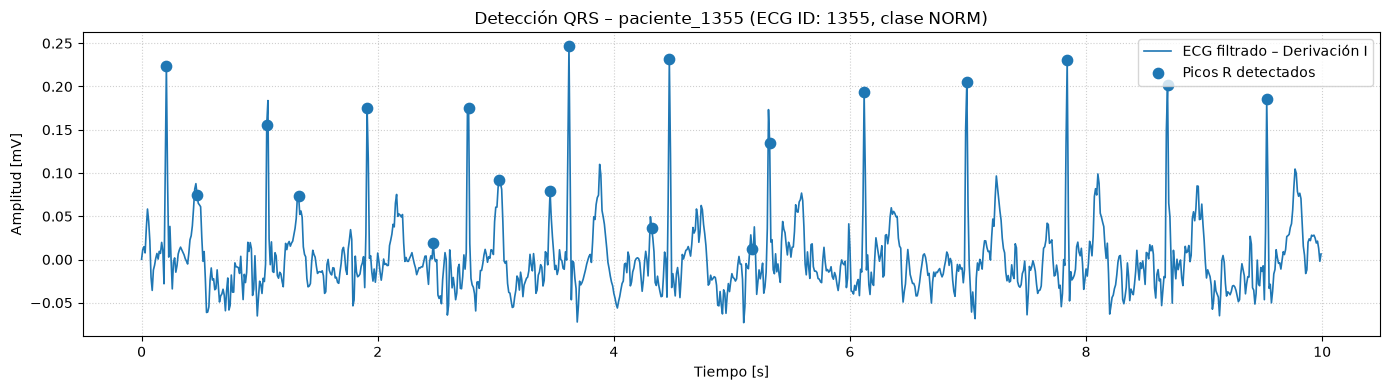

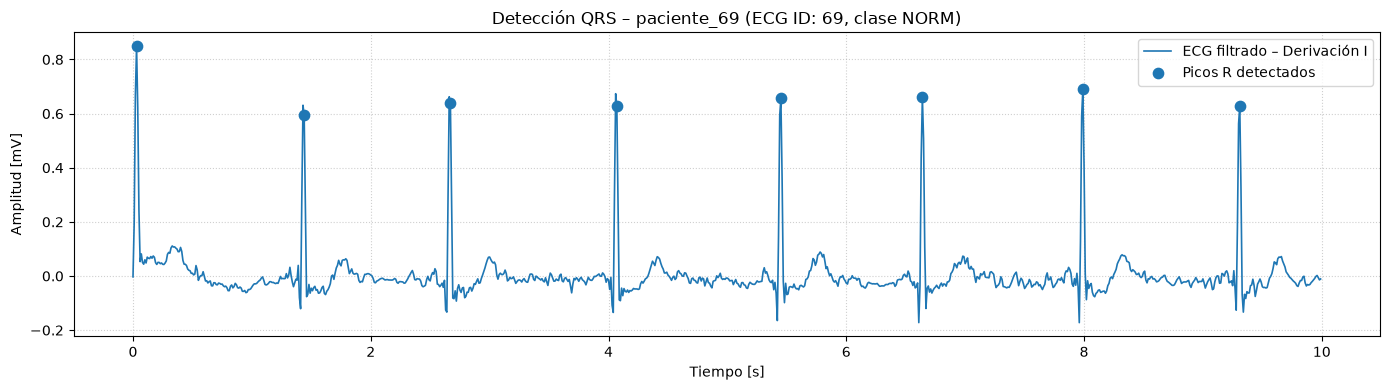

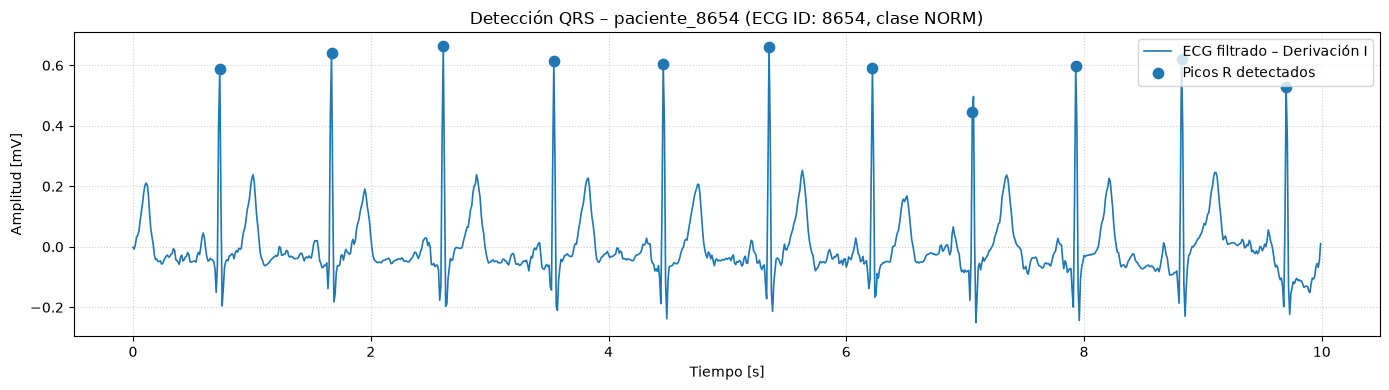

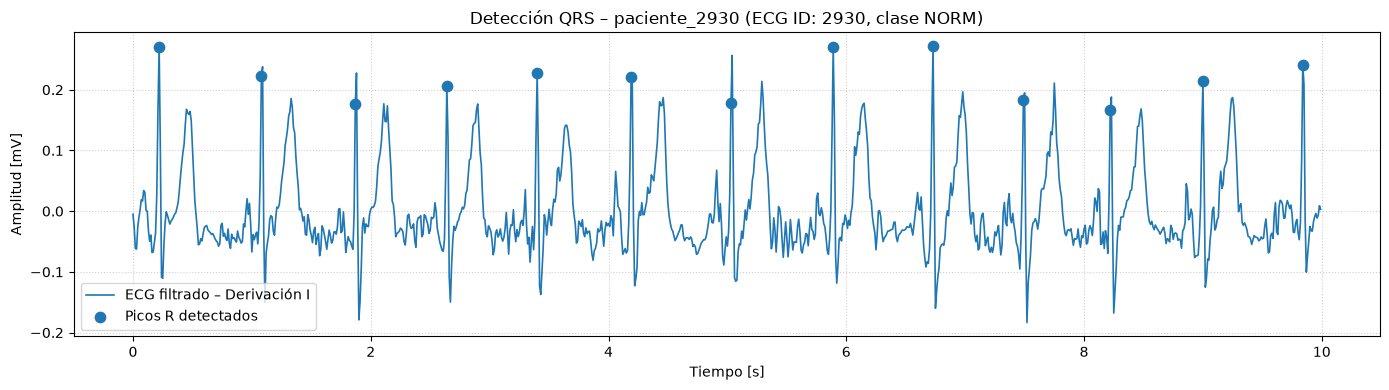

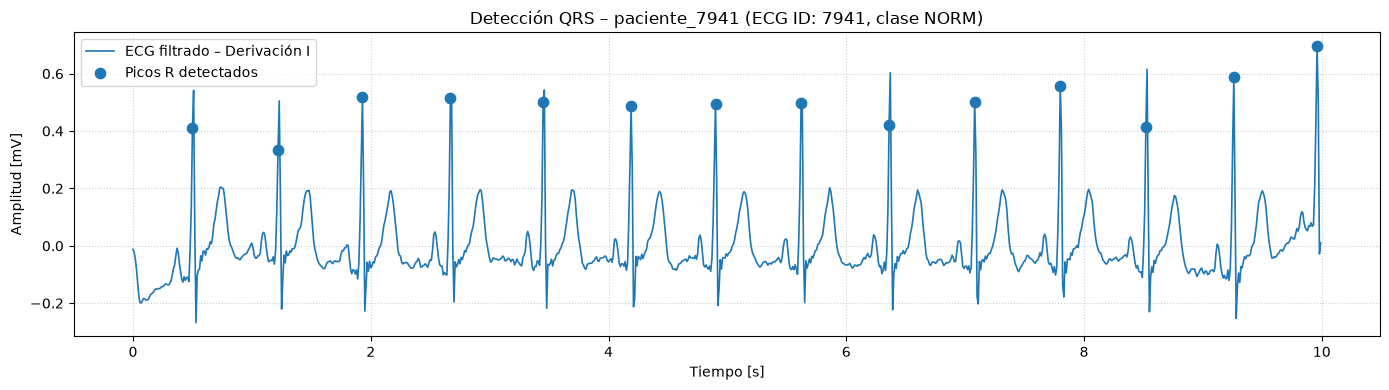

In [41]:
# =============================================================================
# VISUALIZACIÓN DE EJEMPLOS DE DETECCIÓN QRS
# =============================================================================

# Cantidad de pacientes normales a visualizar
N_EJEMPLOS = 5

claves_con_picos = [
    clave
    for clave, paciente in pacientes_normales.items()
    if paciente.get("indices_ondas_r") is not None
]

n_mostrar = min(N_EJEMPLOS, len(claves_con_picos))

if n_mostrar == 0:
    print("No hay registros con picos R detectados para graficar.")

else:
    for clave_paciente in claves_con_picos[:n_mostrar]:
        paciente = pacientes_normales[clave_paciente]

        senal = np.asarray(paciente["senal_I_limpia"])
        picos_r = np.asarray(paciente["indices_ondas_r"], dtype=int)
        fs = float(paciente["fs"])

        tiempo = np.arange(len(senal)) / fs

        plt.figure(figsize=(14, 4))

        plt.plot(
            tiempo,
            senal,
            linewidth=1.2,
            label="ECG filtrado – Derivación I"
        )

        plt.scatter(
            tiempo[picos_r],
            senal[picos_r],
            s=55,
            marker="o",
            label="Picos R detectados",
            zorder=3
        )

        plt.title(
            f"Detección QRS – {clave_paciente} "
            f"(ECG ID: {paciente['ecg_id']}, clase NORM)"
        )
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud [mV]")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()